In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

In [ ]:
TICKERS = {"Oil": "BZ=F", "CAD": "CAD=X", "NOK": "NOK=X", "EUR": "EUR=X"}
START, END = "2016-01-01", "2026-01-01"

def close_series(ticker):
    """Download one ticker and return a named one-dimensional adjusted-close series."""
    data = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False, threads=False)
    if data.empty:
        raise RuntimeError(f"No data returned for {ticker}. Check the ticker or network connection.")
    close = data["Close"]
    if isinstance(close, pd.DataFrame):  # yfinance can return MultiIndex columns
        close = close.iloc[:, 0]
    return close.rename(ticker)

prices = pd.concat({name: close_series(ticker) for name, ticker in TICKERS.items()}, axis=1)
prices = prices.sort_index().dropna()
if prices.empty:
    raise RuntimeError("No dates remain after aligning the price series.")

print(prices.head())
print("Observations after alignment:", len(prices))

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
2016-01-08  33.549999  1.41020  8.88579  0.91525
Observations after alignment: 2511


/var/folders/96/3hvb43kd39n3t4zqv9kjf39m0000gn/T/ipykernel_44062/3332133334.py:14: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  prices = pd.concat({name: close_series(ticker) for name, ticker in TICKERS.items()}, axis=1)


In [150]:
prices = pd.DataFrame({
    "Oil": oil["Close"].squeeze(),
    "CAD": cad["Close"].squeeze(),
    "NOK": nok["Close"].squeeze(),
    "EUR": eur["Close"].squeeze()
})
prices.to_csv("prices.csv")

In [ ]:
# Yahoo's CAD=X, NOK=X, and EUR=X quote local-currency units per USD.
# We convert below to USD per unit of currency for like-for-like FX comparison.
print(prices.head())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
2016-01-08  33.549999  1.41020  8.88579  0.91525


In [ ]:
print(prices.isna().sum())

Oil    0
CAD    0
NOK    0
EUR    0
dtype: int64


In [ ]:
# Missing dates were removed during the common-date alignment in the download cell.
prices = prices.copy()

In [122]:
print(prices.head())
print(prices.isna().sum())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
2016-01-08  33.549999  1.41020  8.88579  0.91525
Oil    0
CAD    0
NOK    0
EUR    0
dtype: int64


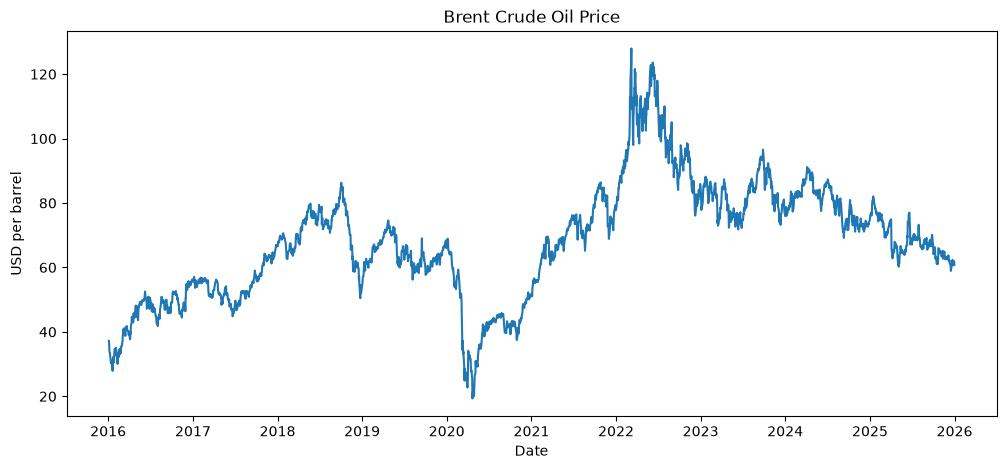

In [123]:
#plotting brent separately bcuz the scale differs by a lot
plt.figure(figsize=(12, 5))

plt.plot(prices.index, prices["Oil"])

plt.title("Brent Crude Oil Price")
plt.xlabel("Date")
plt.ylabel("USD per barrel")

plt.show()

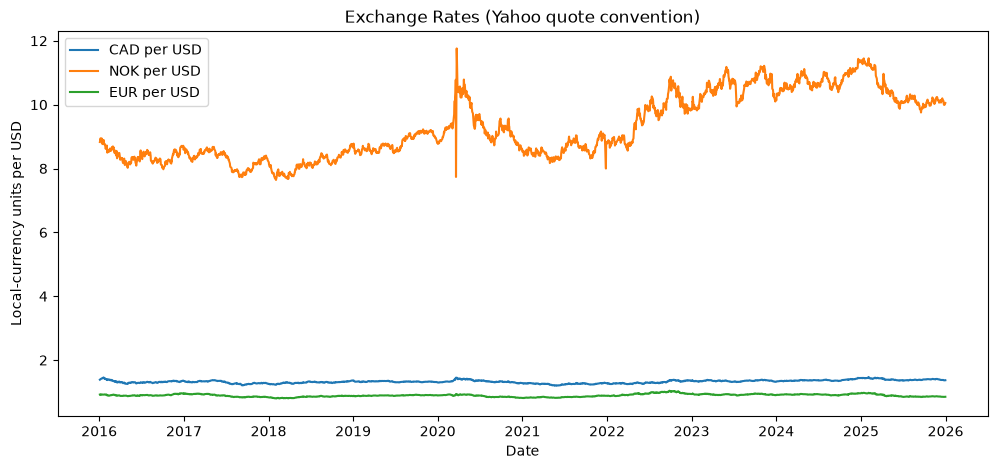

In [ ]:
plt.figure(figsize=(12, 5))
for currency in ["CAD", "NOK", "EUR"]:
    plt.plot(prices.index, prices[currency], label=f"{currency} per USD")
plt.title("Exchange Rates (Yahoo quote convention)")
plt.xlabel("Date")
plt.ylabel("Local-currency units per USD")
plt.legend()
plt.show()

In [125]:
print(prices.head())

                  Oil      CAD      NOK      EUR
Date                                            
2016-01-04  37.220001  1.38645  8.82864  0.92132
2016-01-05  36.419998  1.39343  8.87845  0.92357
2016-01-06  34.230000  1.39840  8.90585  0.93006
2016-01-07  33.750000  1.40676  8.94605  0.92773
2016-01-08  33.549999  1.41020  8.88579  0.91525


In [ ]:
# Convert Yahoo's local-currency-per-USD quotes into USD per local-currency unit.
prices[["CAD", "NOK", "EUR"]] = 1 / prices[["CAD", "NOK", "EUR"]]

In [127]:
print(prices.head())

                  Oil       CAD       NOK       EUR
Date                                               
2016-01-04  37.220001  0.721267  0.113268  1.085399
2016-01-05  36.419998  0.717654  0.112632  1.082755
2016-01-06  34.230000  0.715103  0.112286  1.075199
2016-01-07  33.750000  0.710853  0.111781  1.077900
2016-01-08  33.549999  0.709119  0.112539  1.092598


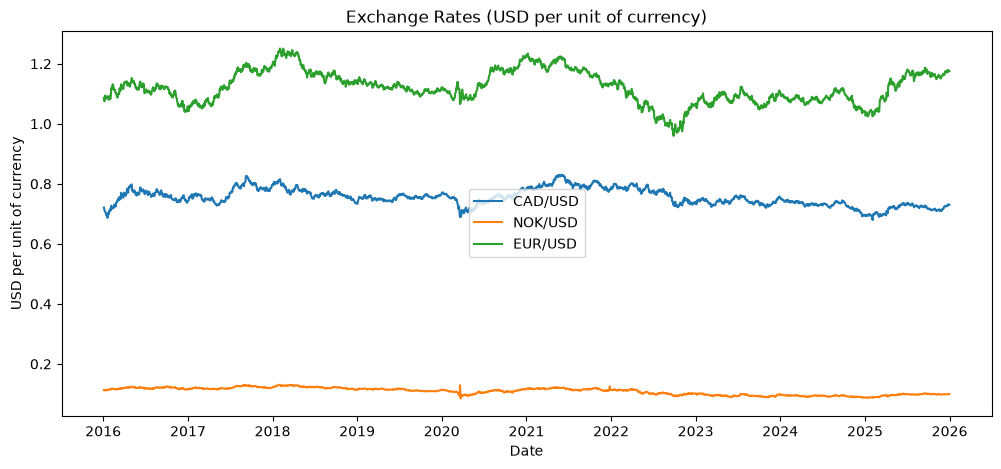

In [ ]:
plt.figure(figsize=(12, 5))
for currency in ["CAD", "NOK", "EUR"]:
    plt.plot(prices.index, prices[currency], label=f"{currency}/USD")
plt.title("Exchange Rates (USD per unit of currency)")
plt.xlabel("Date")
plt.ylabel("USD per unit of currency")
plt.legend()
plt.show()

$$
return=\frac{P_t-P_{t-1}}{P_{t-1}}
$$

In [ ]:
# Log returns are additive across time and standard for daily-return regressions.
returns = np.log(prices).diff().dropna()
if returns.empty:
    raise RuntimeError("Not enough aligned price observations to calculate returns.")
print(returns.head())

                 Oil       CAD       NOK       EUR
Date                                              
2016-01-05 -0.021728 -0.005022 -0.005626 -0.002439
2016-01-06 -0.062016 -0.003560 -0.003081 -0.007003
2016-01-07 -0.014122 -0.005960 -0.004504  0.002508
2016-01-08 -0.005944 -0.002442  0.006759  0.013544
2016-01-11 -0.061463 -0.005798  0.001659  0.001378


In [151]:
returns.to_csv("returns.csv")

In [130]:
corr_cad = returns["Oil"].corr(returns["CAD"])
corr_nok = returns["Oil"].corr(returns["NOK"])
corr_eur = returns["Oil"].corr(returns["EUR"])

print("Oil-CAD:", corr_cad)
print("Oil-NOK:", corr_nok)
print("Oil-EUR:", corr_eur)

Oil-CAD: 0.07926287747816664
Oil-NOK: 0.016016562168152285
Oil-EUR: -0.018536149833524744


In [131]:
#rolling 60day correlation
rolling_cad = returns["Oil"].rolling(60).corr(returns["CAD"])
rolling_nok = returns["Oil"].rolling(60).corr(returns["NOK"])
rolling_eur = returns["Oil"].rolling(60).corr(returns["EUR"])

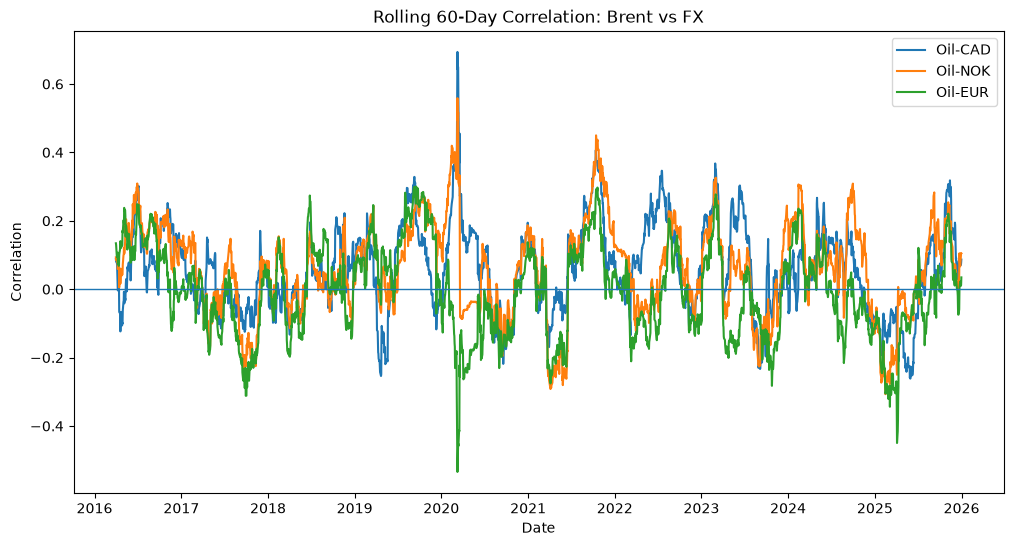

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(rolling_cad, label="Oil-CAD")
plt.plot(rolling_nok, label="Oil-NOK")
plt.plot(rolling_eur, label="Oil-EUR")

plt.axhline(0, linewidth=1)

plt.title("Rolling 60-Day Correlation: Brent vs FX")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()

plt.show()

OLS regression

$$
r_{FX,t}=\alpha+\beta r_{oil,t}+\epsilon_t
$$
where $\beta$ measures the sensitivity of currency returns to Brent crude oil returns

In [ ]:
X = sm.add_constant(returns[["Oil"]])
y = returns["CAD"]
model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     15.86
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           7.03e-05
Time:                        21:18:00   Log-Likelihood:                 10072.
No. Observations:                2510   AIC:                        -2.014e+04
Df Residuals:                    2508   BIC:                        -2.013e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.151e-06   8.74e-05      0.025      0.9

0.014 percent increase in CAD in 1 percent increase of oil price (explained by beta). but r square is small, oil only explains 0.6% of the change in CAD

In [134]:
models = {}
X = sm.add_constant(returns[["Oil"]])
for currency in ["CAD", "NOK", "EUR"]:
    models[currency] = sm.OLS(returns[currency], X, missing="drop").fit()
print(models.keys())


dict_keys(['CAD', 'NOK', 'EUR'])


In [135]:
print(models["CAD"].summary())
print(models["NOK"].summary())
print(models["EUR"].summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     15.86
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           7.03e-05
Time:                        21:18:00   Log-Likelihood:                 10072.
No. Observations:                2510   AIC:                        -2.014e+04
Df Residuals:                    2508   BIC:                        -2.013e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.151e-06   8.74e-05      0.025      0.9

In [ ]:
ols_table = pd.DataFrame({currency: {"Oil Beta": model.params["Oil"], "p-value": model.pvalues["Oil"], "R-squared": model.rsquared} for currency, model in models.items()}).T
ols_table

,Oil Beta,p-value,R-squared
CAD,0.014085,0.000070,0.006283
NOK,0.008572,0.422507,0.000257
EUR,-0.003522,0.353264,0.000344


NOK and EUR show no statistically meaningful daily association with Brent in this simple one-factor setup.

In [ ]:
ols_table.round(3)

,Oil Beta,p-value,R-squared
CAD,0.014,0.000,0.006
NOK,0.009,0.423,0.000
EUR,-0.004,0.353,0.000


define oil shock (1): highest returns in the last 10 years

In [138]:
# An oil shock is a daily oil log return in the upper 5% of its sample distribution.
threshold = returns["Oil"].quantile(0.95)
returns = returns.assign(Oil_Shock=(returns["Oil"] > threshold).astype(int))


In [139]:
returns["Oil_Shock"].value_counts()

Oil_Shock
0    2384
1     126
Name: count, dtype: int64

compare currency response to shocks

In [ ]:
normal = returns.loc[returns["Oil_Shock"] == 0]
shock = returns.loc[returns["Oil_Shock"] == 1]
shock_corr_table = pd.DataFrame({"Normal": {currency: normal["Oil"].corr(normal[currency]) for currency in ["CAD", "NOK", "EUR"]}, "Shock": {currency: shock["Oil"].corr(shock[currency]) for currency in ["CAD", "NOK", "EUR"]}})
shock_corr_table

,Normal,Shock
CAD,0.093772,0.011363
NOK,0.024190,0.046996
EUR,0.002701,-0.018528


define oil shock(2): add in interaction -- currency response is stronger during oil shock.

$$
r_{FX,t}=\alpha+\beta_1 r_{oil,t}+\beta_2 Shock_t+\beta_3(r_{oil,t}\times Shock_t)+\epsilon_t
$$

In [141]:
returns["Oil_Shock_Return"] = (
    returns["Oil"]
    *
    returns["Oil_Shock"]
)

In [ ]:
returns = returns.assign(Oil_Shock_Return=returns["Oil"] * returns["Oil_Shock"])

In [145]:
X = sm.add_constant(returns[["Oil", "Oil_Shock", "Oil_Shock_Return"]])
y = returns["CAD"]
cad_shock_model = sm.OLS(y, X, missing="drop").fit()
print(cad_shock_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAD   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     6.947
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           0.000118
Time:                        21:27:45   Log-Likelihood:                 10075.
No. Observations:                2510   AIC:                        -2.014e+04
Df Residuals:                    2506   BIC:                        -2.012e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4.953e-05   9.02e-05  

Extreme positive oil days did not materially strengthen the CAD relationship: the shock-interaction term was not statistically significant (p ≈ 0.30).

In [146]:
X = returns[["Oil", "Oil_Shock", "Oil_Shock_Return"]]
X = sm.add_constant(X)
y = returns["NOK"]

nok_shock_model = sm.OLS(y, X, missing="drop").fit()

print(nok_shock_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    NOK   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6311
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.595
Time:                        21:27:53   Log-Likelihood:                 7297.8
No. Observations:                2510   AIC:                        -1.459e+04
Df Residuals:                    2506   BIC:                        -1.456e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              2.29e-05      0.000  

In [147]:
X = returns[["Oil", "Oil_Shock", "Oil_Shock_Return"]]
X = sm.add_constant(X)
y = returns["EUR"]

eur_shock_model = sm.OLS(y, X, missing="drop").fit()

print(eur_shock_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    EUR   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.411
Date:                Sun, 23 Aug 2026   Prob (F-statistic):              0.238
Time:                        21:28:05   Log-Likelihood:                 9898.3
No. Observations:                2510   AIC:                        -1.979e+04
Df Residuals:                    2506   BIC:                        -1.977e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.701e-05   9.68e-05  

In [149]:
shock_ols_table = pd.DataFrame({
    "Oil Beta": [
        cad_shock_model.params["Oil"],
        nok_shock_model.params["Oil"],
        eur_shock_model.params["Oil"],
    ],
    "Shock Dummy Beta": [
        cad_shock_model.params["Oil_Shock"],
        nok_shock_model.params["Oil_Shock"],
        eur_shock_model.params["Oil_Shock"],
    ],
    "Shock Interaction Beta": [
        cad_shock_model.params["Oil_Shock_Return"],
        nok_shock_model.params["Oil_Shock_Return"],
        eur_shock_model.params["Oil_Shock_Return"],
    ],
    "Oil p-value": [
        cad_shock_model.pvalues["Oil"],
        nok_shock_model.pvalues["Oil"],
        eur_shock_model.pvalues["Oil"],
    ],
    "Interaction p-value": [
        cad_shock_model.pvalues["Oil_Shock_Return"],
        nok_shock_model.pvalues["Oil_Shock_Return"],
        eur_shock_model.pvalues["Oil_Shock_Return"],
    ],
    "R-squared": [
        cad_shock_model.rsquared,
        nok_shock_model.rsquared,
        eur_shock_model.rsquared,
    ],
}, index=["CAD", "NOK", "EUR"])

shock_ols_table.round(4)

,Oil Beta,Shock Dummy Beta,Shock Interaction Beta,Oil p-value,Interaction p-value,R-squared
CAD,0.0191,-0.0001,-0.0168,0.0000,0.2971,0.0082
NOK,0.0152,-0.0016,0.0004,0.2305,0.9928,0.0008
EUR,0.0006,-0.0007,-0.0041,0.8952,0.8134,0.0017


none of the oil-shock interaction terms is statistically significant.